<a href="https://colab.research.google.com/github/sdtasneem/AIDS-Projects/blob/main/Breast_cancer_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**import required libraries**

In [ ]:
# Import libraries for data handling and accessing the Kaggle dataset
import pandas as pd
import kagglehub as kb
import os

Using Colab cache for faster access to the 'breast-cancer-wisconsin-data' dataset.


**Dataset URL**

In [ ]:
# Store the Kaggle dataset URL
u="https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data.csv"

**Download and load the dataset**

In [ ]:
# Download the Breast Cancer Wisconsin dataset from Kaggle
path=kb.dataset_download("uciml/breast-cancer-wisconsin-data")
# Get the path of the CSV file
file=os.path.join(path,'data.csv')
# Read the dataset into a DataFrame
df=pd.read_csv(file)

**View the first few records**

In [ ]:
# Display the first five rows of the dataset
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


**Display all columns**

In [ ]:
# Set pandas to display all columns without hiding any of them
pd.set_option("display.max_columns",None)

In [ ]:
df

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,1.1760,1.2560,7.673,158.70,0.010300,0.02891,0.05198,0.02454,0.01114,0.004239,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,NaN
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,0.7655,2.4630,5.203,99.04,0.005769,0.02423,0.03950,0.01678,0.01898,0.002498,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,NaN
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,0.4564,1.0750,3.425,48.55,0.005903,0.03731,0.04730,0.01557,0.01318,0.003892,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,NaN
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,0.7260,1.5950,5.772,86.22,0.006522,0.06158,0.07117,0.01664,0.02324,0.006185,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,NaN


**Check dataset information**

In [ ]:
# Check the number of rows, columns, data types and non-null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

**Check missing values**

In [ ]:
# Check the number of missing values in each column
df.isnull().sum()

,0
id,0
diagnosis,0
radius_mean,0
texture_mean,0
perimeter_mean,0
area_mean,0
smoothness_mean,0
compactness_mean,0
concavity_mean,0
concave points_mean,0


**Remove unnecessary column**

In [ ]:
# Remove the unnamed column because it does not contain useful information
df.drop('Unnamed: 32',axis=1,inplace=True)

**Convert categorical values into numbers**

In [ ]:
# Import LabelEncoder to convert categorical values into numerical values
from sklearn.preprocessing import LabelEncoder
Le=LabelEncoder()
col=df.columns
for c in col:
  if df[c].dtypes=='object':
    df[c]=Le.fit_transform(df[c])

In [ ]:
# Display the dataset after converting categorical values into numbers
df

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,842517,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,84300903,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,84348301,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,84358402,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,926424,1,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,1.1760,1.2560,7.673,158.70,0.010300,0.02891,0.05198,0.02454,0.01114,0.004239,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,926682,1,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,0.7655,2.4630,5.203,99.04,0.005769,0.02423,0.03950,0.01678,0.01898,0.002498,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,926954,1,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,0.4564,1.0750,3.425,48.55,0.005903,0.03731,0.04730,0.01557,0.01318,0.003892,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,927241,1,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,0.7260,1.5950,5.772,86.22,0.006522,0.06158,0.07117,0.01664,0.02324,0.006185,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


**Import machine learning libraries**

In [ ]:
# Import Random Forest for feature selection
# RFE is used to select the most important features
# train_test_split is used to divide data into training and testing sets
# StandardScaler is used to scale the input features
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFE
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [ ]:
# Remove the diagnosis column from the input features
features=df.drop('diagnosis',axis=1)

In [ ]:
# X contains the input features
# y contains the target variable (diagnosis)
X=features
y=df['diagnosis']

**Feature selection using RFE**

In [ ]:
# Create a Random Forest classifier
rf=RandomForestClassifier(n_estimators=100,random_state=32)
# Select the top 5 important features using Recursive Feature Elimination
rfe=RFE(estimator=rf,n_features_to_select=5)
# Fit RFE on the input features and target
rfe.fit(X,y)

RFE(estimator=RandomForestClassifier(random_state=32), n_features_to_select=5)

In [ ]:
# Get the names of the five features selected by RFE
selected_features=[f for f,s in zip(features,rfe.support_) if s]
selected_features

['concave points_mean',
 'radius_worst',
 'perimeter_worst',
 'area_worst',
 'concave points_worst']

**Create new dataset using selected features**

In [ ]:
# Create a new input dataset using only the selected features
X_new=df[selected_features]
# Store the target variable separately
y_new=df['diagnosis']

In [ ]:
# Display the target values
y_new

,diagnosis
0,1
1,1
2,1
3,1
4,1
...,...
564,1
565,1
566,1
567,1


**Split data into training and testing sets**

In [ ]:
# Split the data into training and testing sets
# 80% of the data is used for training and 20% for testing
x_train,x_test,y_train,y_test=train_test_split(X_new,y_new,test_size=0.2,random_state=42)

In [ ]:
x_train

,concave points_mean,radius_worst,perimeter_worst,area_worst,concave points_worst
68,0.04375,10.310,65.50,324.7,0.17500
181,0.14960,26.680,176.50,2089.0,0.29030
63,0.02180,10.010,65.59,310.1,0.05087
248,0.01615,12.250,77.98,455.7,0.06136
60,0.01290,11.020,69.86,368.6,0.02579
...,...,...,...,...,...
71,0.02872,9.733,62.56,284.4,0.04786
106,0.03485,13.140,85.51,521.7,0.12180
270,0.00625,14.910,94.44,684.6,0.03333
435,0.06463,17.040,113.90,869.3,0.18270


In [ ]:
y_train

,diagnosis
68,0
181,1
63,0
248,0
60,0
...,...
71,0
106,0
270,0
435,1


**Feature scaling**

In [ ]:
# Create a StandardScaler to bring all features to a similar scale
scaler=StandardScaler()
# Fit the scaler using training data and transform it
x_train_scaler=scaler.fit_transform(x_train)
# Use the same scaler to transform the test data
x_test_scaler=scaler.transform(x_test)

**Save the scaler**

In [ ]:
# Import pickle to save the scaler for future predictions
import pickle
# Save the fitted scaler
with open('scaler.pkl','wb') as f:
  pickle.dump(scaler,f)

**Import TensorFlow and Keras**

In [ ]:
# Import TensorFlow and Keras libraries for building the ANN model
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers,models

**Create the ANN model**

In [ ]:
# Define the Artificial Neural Network architecture                                                                                                                                                             +
def create_model():
  model=models.Sequential([
      layers.Dense(32,input_shape=(x_train_scaler.shape[1],),activation='relu'),
      layers.Dense(16,activation='relu'),
      layers.Dense(8,activation='relu'),
      layers.Dense(1,activation='sigmoid')
      ])
  return model


**Create the model**

In [ ]:
model=create_model()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


**Compile the model**

In [ ]:
# Compile the ANN model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

**Train the ANN**

In [ ]:
# Train the ANN model for 50 epochs
history=model.fit(x_train_scaler,y_train,epochs=50,batch_size=32,validation_split=0.2)

Epoch 1/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 119ms/step - accuracy: 0.3993 - loss: 0.6844 - val_accuracy: 0.4505 - val_loss: 0.6466
Epoch 2/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6281 - loss: 0.6384 - val_accuracy: 0.9121 - val_loss: 0.5981
Epoch 3/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9082 - loss: 0.5844 - val_accuracy: 0.9341 - val_loss: 0.5448
Epoch 4/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8946 - loss: 0.5294 - val_accuracy: 0.9341 - val_loss: 0.4909
Epoch 5/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8942 - loss: 0.4815 - val_accuracy: 0.9341 - val_loss: 0.4347
Epoch 6/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9319 - loss: 0.4098 - val_accuracy: 0.9341 - val_loss: 0.3764
Epoch 7/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9224 - loss: 0.3532 - val_accuracy: 0.9341 - val_loss: 0.3154
Epoch 8/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9294 - loss: 0.3060 - val_accuracy: 0.9451 - val_los

**Plot accuracy**

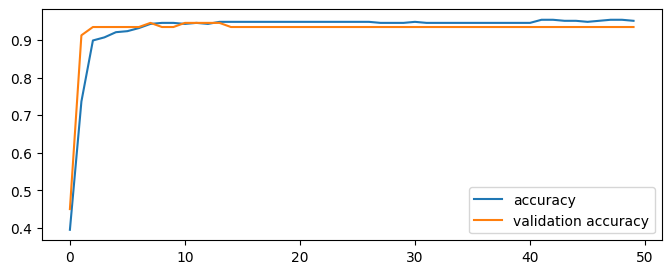

In [ ]:
# Plot training and validation accuracy
import matplotlib.pyplot as plt
plt.figure(figsize=(8,3))
plt.plot(history.history['accuracy'],label="accuracy")
plt.plot(history.history['val_accuracy'],label="validation accuracy")
plt.legend()
plt.show()

**Plot loss**

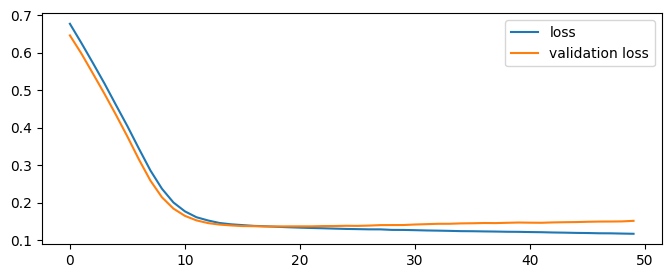

In [ ]:
# Plot training and validation loss
plt.figure(figsize=(8,3))
plt.plot(history.history['loss'],label="loss")
plt.plot(history.history['val_loss'],label="validation loss")
plt.legend()
plt.show()

**Evaluate the model**

In [ ]:
# Evaluate the trained ANN using the unseen test data
loss,accuracy=model.evaluate(x_test_scaler,y_test)
print(f'loss:{loss} and accuracy:{accuracy}')

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.9759 - loss: 0.0770
loss:0.07770992815494537 and accuracy:0.9736841917037964


**Save the trained model**

In [ ]:
# Save the trained ANN model
model.save('breast_cancer_prediction.h5')
with open("selected_features.pkl","wb") as f:
  pickle.dump(selected_features,f)

**Load the saved model**


In [ ]:
# Create a function to load the trained model and preprocessing files
def load_model():
  model=tf.keras.models.load_model('breast_cancer_prediction.h5')
  with open("scaler.pkl","rb") as f:
    scaler=pickle.load(f)
  with open("selected_features.pkl","rb") as f:
    selected_features=pickle.load(f)
  return model,scaler,selected_features

**Create prediction function**

In [ ]:
# Create a function to predict whether the tumor is malignant or benign
def prediction(*args):
  model,scaler,selected_features=load_model()
  input_data = pd.DataFrame([args], columns=selected_features)
  input_scaled = scaler.transform(input_data)
  prediction = model.predict(input_scaled)[0][0]
  print(f"prediction : {prediction}")
  probability = float(prediction)
  diagnosis_status = "Malignant" if probability > 0.50 else "Benign"
  return {
      "cancer Probability":probability,
      "Will patient diagnosis":diagnosis_status
    }

**Test the prediction function**

In [ ]:
# Test the model with a sample input
prediction( 0.02,14.5,95.0,650.0, 0.04)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 584ms/step
prediction : 0.01725156232714653


{'cancer Probability': 0.01725156232714653, 'Will patient diagnosis': 'Benign'}